---
title: "Area Charts"
subtitle: "DS 2023 | Communicating with Data"
---

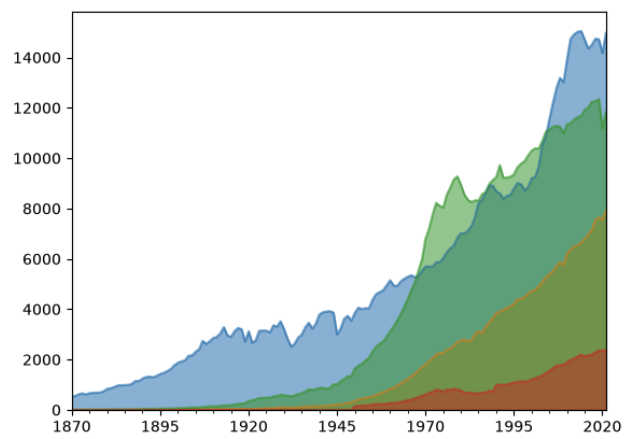

## Overview

Area charts are essentially line graphs in which the area under the line is filled in with color. 

By coloring in the area, the focus shifts from trends to the **accumulation** or **composition** of the value represented by the x axis.

There are two main types of area chart when they involve more than one trend line:

1. **Overlapping**: Area charts with multiple lines to make a comparison between groups.

2. **Stacked**: Area charts that show how a whole is divided into component parts.

Like bar charts and unlike line graphs, area charts should always have a **zero baseline** for the y axis.

In addtion, unlike bar charts, area charts tyoically **do not show negative values**.

## Use Cases

- **Tracking time-series data**, for example monthly sales revenue, daily stock prices, or annual website traffic. 

- **Visualizing part-to-whole relationships over time**, for example budget allocations by department or energy consumption by source. 

- **Highlighting running totals**, for example tracking total donations raised during a campaign or total active users acquired over a year.

- **Comparing lower and upper boundaries**, such as minimum and maximum values, for example daily temperature highs and lows or financial confidence intervals.  

## A simple example

In this example, we look at energy consumption by fuel type from 1870 to 2021.

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

energy = pd.read_csv("energy.csv").set_index('year')
energy.info()
energy

<class 'pandas.DataFrame'>
RangeIndex: 152 entries, 1870 to 2021
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Coal                              152 non-null    float64
 1   Gas                               140 non-null    float64
 2   Oil                               152 non-null    float64
 3   Cement, Flaring & Other Industry  72 non-null     float64
dtypes: float64(4)
memory usage: 4.9 KB


,Coal,Gas,Oil,"Cement, Flaring & Other Industry"
year,,,,
1870,529.404,NaN,3.133,NaN
1871,562.861,NaN,3.282,NaN
1872,622.674,NaN,3.698,NaN
1873,659.749,NaN,5.670,NaN
1874,616.754,NaN,6.243,NaN
...,...,...,...,...
2017,14506.974,7144.928,12242.628,2202.209
2018,14746.831,7529.847,12266.017,2283.813
2019,14725.978,7647.528,12345.653,2363.400


We alter the column names to simplify our visualization.

In [267]:
energy.columns = ['coal', 'gas', 'oil', 'other']

We also convert the index to a `datatime` data type.

> [!tip] Converting dates to `datatime` types improves how Pandas' plot method interprets and displays the data.

In [268]:
# energy.index = energy.index.astype(int)
energy.index = pd.to_datetime(energy.index.astype(str), format='%Y')
energy

,coal,gas,oil,other
year,,,,
1870-01-01,529.404,NaN,3.133,NaN
1871-01-01,562.861,NaN,3.282,NaN
1872-01-01,622.674,NaN,3.698,NaN
1873-01-01,659.749,NaN,5.670,NaN
1874-01-01,616.754,NaN,6.243,NaN
...,...,...,...,...
2017-01-01,14506.974,7144.928,12242.628,2202.209
2018-01-01,14746.831,7529.847,12266.017,2283.813
2019-01-01,14725.978,7647.528,12345.653,2363.400


Upon inspection, we notice a lot of null values.

We can interpret these as true absences, not faulty data collection.

In [269]:
energy = energy.fillna(0)
energy

,coal,gas,oil,other
year,,,,
1870-01-01,529.404,0.000,3.133,0.000
1871-01-01,562.861,0.000,3.282,0.000
1872-01-01,622.674,0.000,3.698,0.000
1873-01-01,659.749,0.000,5.670,0.000
1874-01-01,616.754,0.000,6.243,0.000
...,...,...,...,...
2017-01-01,14506.974,7144.928,12242.628,2202.209
2018-01-01,14746.831,7529.847,12266.017,2283.813
2019-01-01,14725.978,7647.528,12345.653,2363.400


### Stacked 

In the chart below, the four lines and their areas are stacked on top of each other. 

The chart shows both the overall growth of energy consumption and the relative contribution of each fuel.

You can see, for example, that before around 1945, coal is the dominant source of energy. After that, oil consumption grows to rival it.

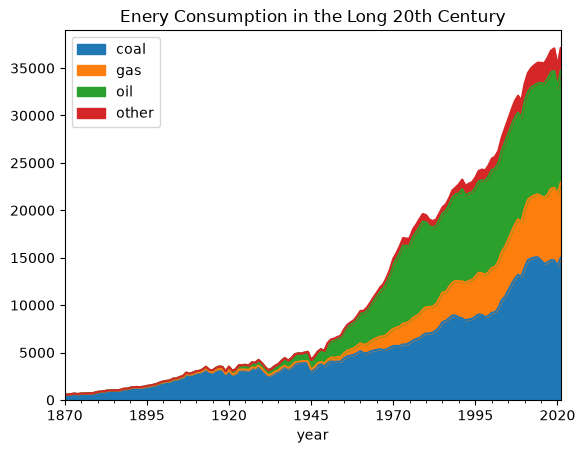

In [270]:
plot_title = "Enery Consumption in the Long 20th Century"
energy.plot.area(title=plot_title)
plt.show()

### Unstacked

If we set that stacked for `False`, what we see if the relative growth of each fuel type, but not the overall growth.

In this chart, we can see more clearly that although oil consumption grows rapidly after WWII, it still does not exceed the use of coal.

We can see, however, that from around the late 1960s to the turn of the century, gas use _did_ exceed coal use. 

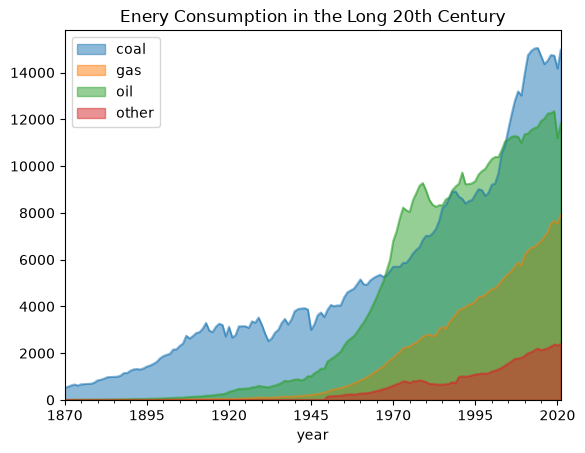

In [271]:
energy.plot.area(stacked=False, title=plot_title)
plt.show()

Note that the unstacked chart is similar to the basic line graph in not showing combined amounts.

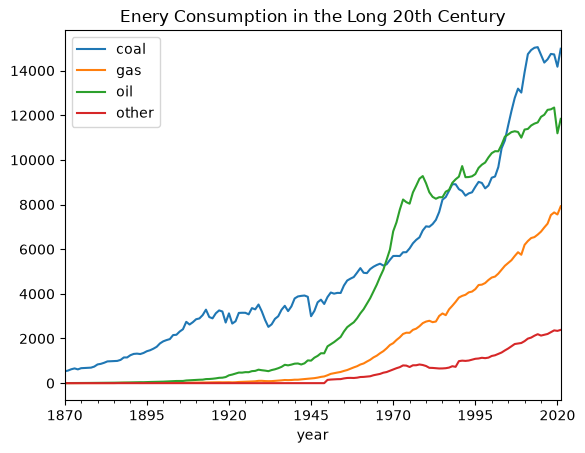

In [272]:
energy.plot(title=plot_title)
plt.show()

### Stacked with normed data

Now, if we want to show the relative amounts of fuel consumption over time without regard to absolute values, we can normalize the data so that the value of consumption for each year sums to $1$.

This shows rather dramatically how the use of other fuels grow relative to coal.

In [304]:
energy_norm = energy.div(energy.sum(axis=1), axis=0)
# energy_norm = energy.apply(lambda x: x / x.sum(), axis=1) # Another way to compute this
# energy_norm = (energy.T / energy.T.sum()).T
energy_norm

,coal,gas,oil,other
year,,,,
1870-01-01,0.994117,0.000000,0.005883,0.000000
1871-01-01,0.994203,0.000000,0.005797,0.000000
1872-01-01,0.994096,0.000000,0.005904,0.000000
1873-01-01,0.991479,0.000000,0.008521,0.000000
1874-01-01,0.989979,0.000000,0.010021,0.000000
...,...,...,...,...
2017-01-01,0.401892,0.197938,0.339162,0.061009
2018-01-01,0.400441,0.204468,0.333076,0.062015
2019-01-01,0.397113,0.206230,0.332923,0.063733


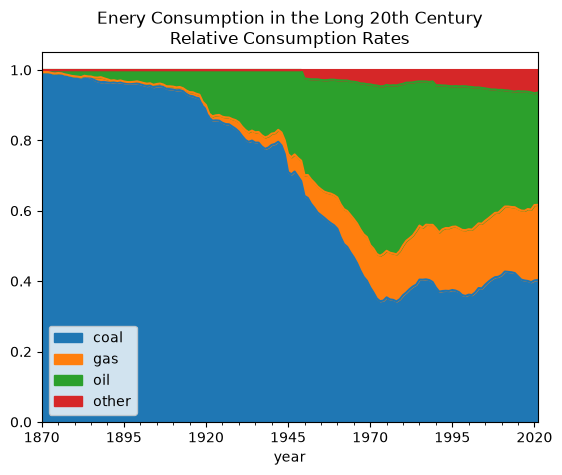

In [305]:
energy_norm.plot.area(title=plot_title + "\nRelative Consumption Rates")
plt.show()

### Unstacked with normed data

We can also show the normed data without stacking.

Again we see that coal consumption declines as oil increases.

We can also see clearly the period in which oil exceeds coal.

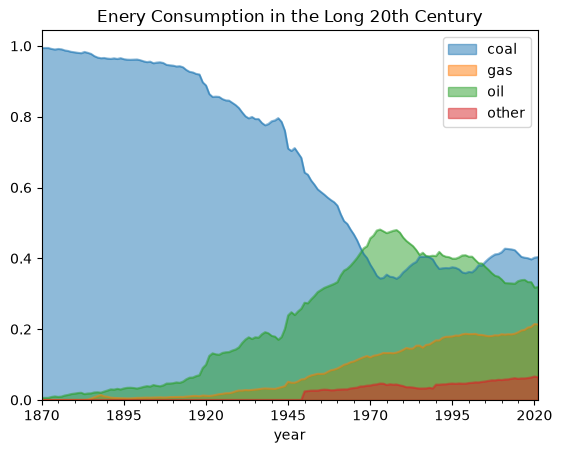

In [306]:
energy_norm.plot.area(stacked=False, title=plot_title)
plt.show()

### Aside: Comparison to pie charts

Since we are showing composition of energy use, where the domain is small, we might compare area charts to pie charts.

Here is how we might accomplish the changing composition of energy use over time with pie charts.

First, let's group our date by decade and get the means for each energy type.

In [307]:
energy_decade = energy.groupby(energy.index.year // 10 * 10).mean().fillna(0)
energy_decade

,coal,gas,oil,other
year,,,,
1870,646.7244,0.0000,6.5922,0.0000
1880,989.9688,5.3897,20.3623,0.0000
1890,1439.5554,8.2938,47.3785,0.0000
1900,2292.6270,16.7065,98.1947,0.0000
1910,3027.7778,32.3901,198.8417,0.0000
1920,3128.6390,62.3619,477.9464,0.0000
1930,3048.7612,113.2491,672.9403,0.0000
1940,3652.0485,212.2523,1054.0827,0.0000
1950,4336.2656,543.7479,2232.1523,199.1759


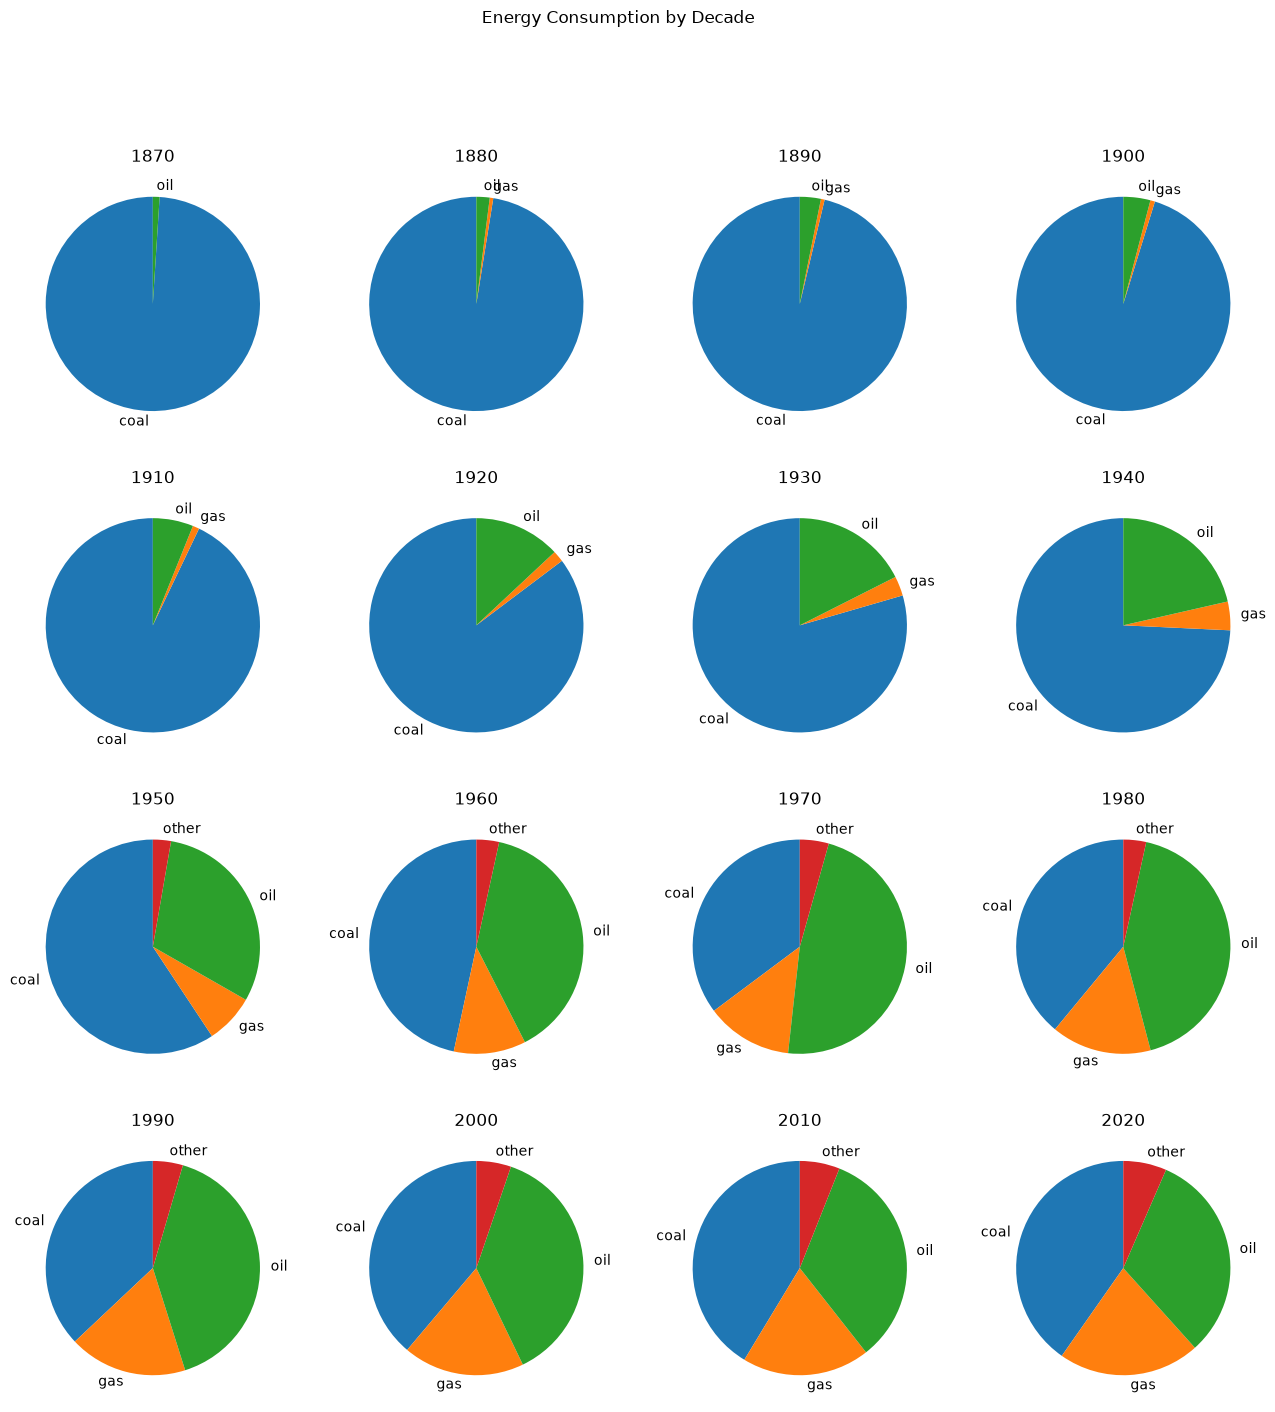

In [308]:
ax = energy_decade.T.plot.pie(
    subplots=True, 
    figsize=(16,16), 
    legend=False, 
    layout=(4,4),  # Since there are 16 decades represented
    startangle=90,
)
for i, ax in enumerate(ax.flatten()):
    ax.set_axis_off()
    my_label = energy_decade.index[i]
    ax.set_title(my_label)
plt.suptitle("Energy Consumption by Decade")
plt.show()

## Difference charts

Let's look more closely at the relationship between coal and oil after WWII.

A simple line graph shows the growth and competetion between the two.

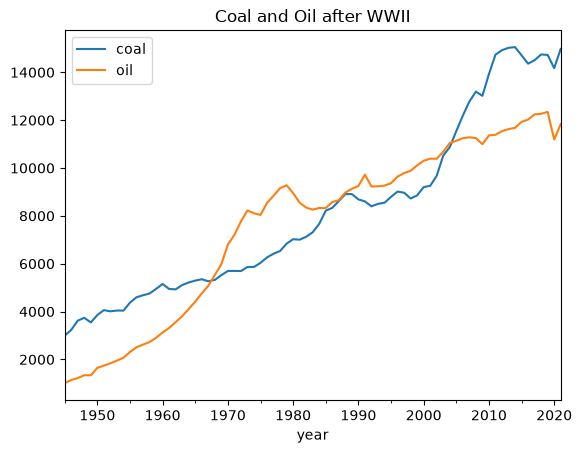

In [317]:
coal_and_oil = energy.query("year >= 1945")[['coal','oil']]
plot_title2 = "Coal and Oil after WWII"
coal_and_oil.plot(title=plot_title2)
plt.show()

This is a good candidate for a **difference chart**, a variant of the area chart.

A difference chart is an area chart where only the areas of curve overlap are shaded.

A good example of this is William Playfair's famous trade-balance chart from 1786:

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/52/Playfair_TimeSeries-2.png/1280px-Playfair_TimeSeries-2.png" width="1000"/>Playfair's trade-balance time-series chart, published in Commercial and Political Atlas, 1786.
From [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Playfair_TimeSeries-2.png)


Heris a more contemporary example:

<!-- ![](../../images/eco3min-diff-chart.png) -->

<img src="https://eco3min.fr/wp-content/uploads/2026/08/cycle11_chart_desktop_16x9-1.png" width="1000" />

[Source: Eco3min](https://eco3min.fr/en/us-children-vs-adults-65-and-older/)

Let's try to reproduce this effect with Pandas and Matplotlib.

One approach is to create a third column that consists of the minimum values of `coal` and `oil`.

In [323]:
coal_and_oil['min'] = coal_and_oil.min(axis=1)
coal_and_oil.head()

,coal,oil,min
year,,,
1945-01-01,2998.270,1008.345,1008.345
1946-01-01,3234.314,1139.899,1139.899
1947-01-01,3621.548,1221.313,1221.313
1948-01-01,3739.455,1339.607,1339.607
1949-01-01,3546.310,1336.641,1336.641


Now, If we plot `min` and set its color to white, it will mask everything except the overlaps.

Here's how the three lines look as a line graph:

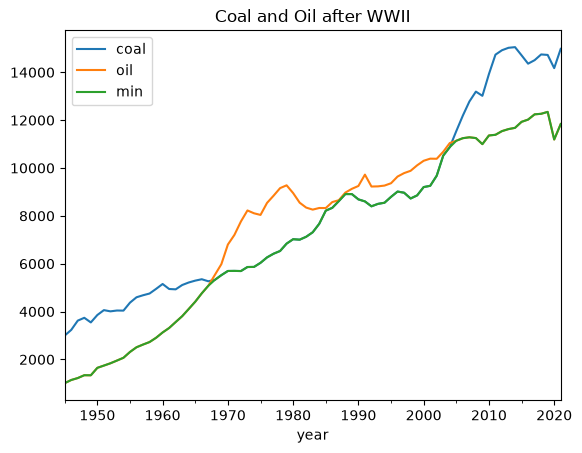

In [324]:
coal_and_oil.plot(title=plot_title2)
plt.show()

Now let's view them as an difference chart:

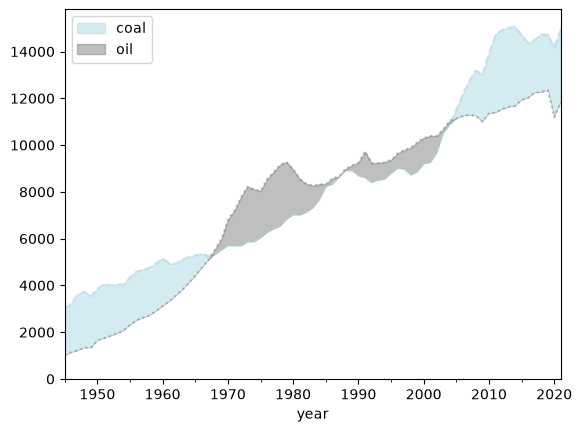

In [325]:
# First plot coal and oil
coal_and_oil[['coal','oil']].plot.area(stacked=False, color=['lightblue','gray'], style=['--',':'])

# Then plot min as a mask
coal_and_oil['min'].plot.area(color='white', lw=0)

plt.show()

## Caveats

Although each of these charts gives insight to energy consumption over time, it is important to convey to the reader just what they are looking at.

In the first diagram, where the curves are stacked, a reader might think that coal has the least usage since it is on the bottom.

Even if readers known that the plots are stacked, their eyes may deceive them into thinking that all of the fuel usages are always rising. 

But we know that coal usage actually declines for something like a $40$ year period.

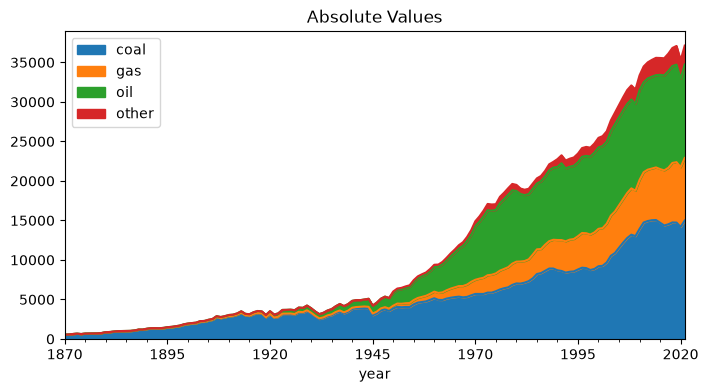

In [288]:
energy.plot.area(stacked=True, title="Absolute Values", figsize=(8,4))
plt.show()

Another source of confusion occurs when an area chart of normalized data is presented. 

Consider how the relative proportion of coal usage decreases even though the absolute usage increases (see image below).

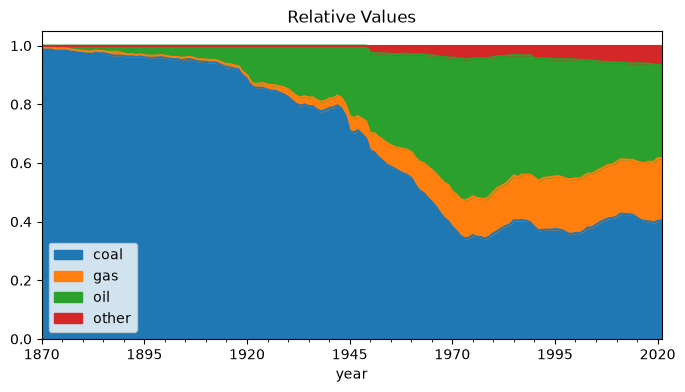

In [289]:
energy_norm.plot.area(stacked=True, title="Relative Values", figsize=(8,4))
plt.show()